In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("indiv_spearman_duplicates_grouped_norepeat_Specificity_model_mlp.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q3 < 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("indiv_features_with_negative_IQR_Specificity_model_mlp.csv", index=False)


                                  Feature     Q1     Q3  \
0                            crRNA spacer -0.608 -0.286   
1   bh_maximal consecutive unpaired bases -0.811 -0.712   
2                          bh_5' overhang -0.609 -0.544   
3                              bh_5' stem -0.445 -0.344   
4     ah_maximal consecutive paired bases -0.925 -0.874   
5   ah_maximal consecutive unpaired bases -0.897 -0.855   
6                          ah_3' overhang -0.675 -0.523   
7                              ah_5' stem -0.551 -0.353   
8                     PAM-proximal region -0.852 -0.811   
9                          central region -0.926 -0.864   
10                      PAM-distal region -0.964 -0.950   

    Median Spearman Correlation  
0                        -0.476  
1                        -0.766  
2                        -0.570  
3                        -0.390  
4                        -0.900  
5                        -0.864  
6                        -0.627  
7                  

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_37239/69848139.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


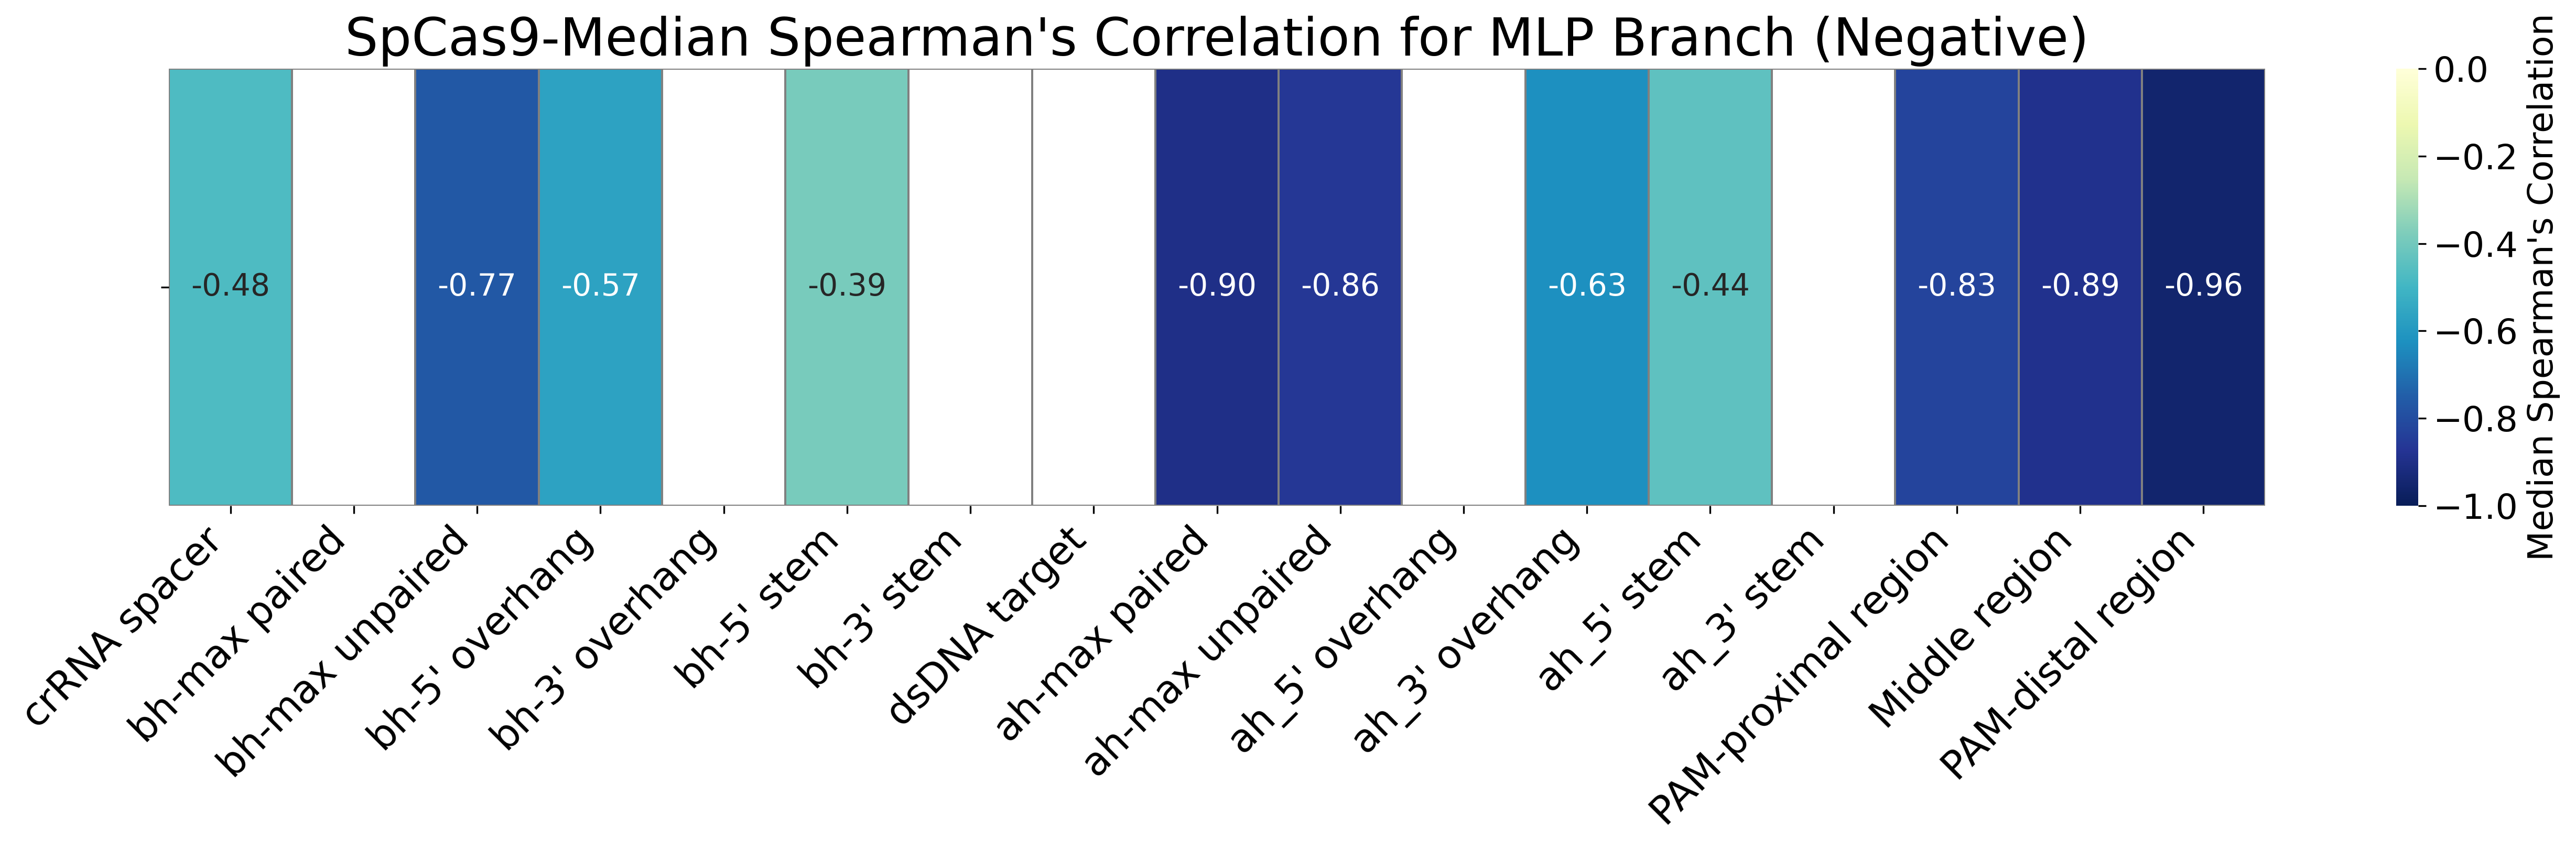

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- desired full feature order (17 columns) ----
feature_order = [
    "crRNA spacer",
    "bh_maximal consecutive paired bases",
    "bh_maximal consecutive unpaired bases",
    "bh_5' overhang",
    "bh_3' overhang",
    "bh_5' stem",
    "bh_3' stem",
    "dsDNA target",
    "ah_maximal consecutive paired bases",
    "ah_maximal consecutive unpaired bases",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "central region",
    "PAM-distal region"
]

csv_path = "indiv_features_with_negative_IQR_Specificity_model_mlp.csv"
value_col = "Median Spearman Correlation"   # change if your column name differs
feature_col = "Feature"                     # change if your feature-name column differs

# ---- load ----
df = pd.read_csv(csv_path)

# Optional: if duplicates exist, average them
df = df.groupby(feature_col, as_index=False)[value_col].mean()

# ---- build a 1x17 table: row label "MLP", columns are the 17 features ----
# Map available features into a Series indexed by Feature name
s = df.set_index(feature_col)[value_col]

# Reindex to force all 17 features to exist; missing -> NaN
s = s.reindex(feature_order)

heatmap_data = pd.DataFrame([s.values], index=[""], columns=feature_order)

# ---- plot (NaN will be blank if masked) ----
mask = heatmap_data.isna()

fig, ax = plt.subplots(figsize=(18, 5.5), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu_r",
    vmin=-1, vmax=0,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Median Spearman's Correlation"},
    annot_kws={"fontsize": 14},
    ax=ax
)

ax.set_ylabel("")  # 1-row heatmap; optional
ax.set_xlabel("")
ax.set_title("SpCas9-Median Spearman's Correlation for MLP Branch (Negative)", fontsize=24)

# Rotate x tick labels + align to the right (NOTE: use set_xticklabels for alignment)
short_labels = [
    "crRNA spacer",
    "bh-max paired",
    "bh-max unpaired",
    "bh-5' overhang",
    "bh-3' overhang",
    "bh-5' stem",
    "bh-3' stem",
    "dsDNA target",
    "ah-max paired",
    "ah-max unpaired",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "Middle region",
    "PAM-distal region"
]

ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()
